Dimitrescu Robert-Sebastian 312CA - World Cup 2026 player value prediction

This project follows to predict current market value prices of World Cup 2026 players (regression problem). Most tragic data outlier is Romania not having a team at the World Cup!

In [133]:
import pandas as pd
import numpy as np
import requests
import io
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from adjustText import adjust_text
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

First data source: 2026_FIFA_World_Cup_squads from Wikipedia, using because it lists important data about the players such as: 

* official appearances a player has made for the national team
* for what club they play
* age
* name
* position

Scraped using this tutorial to make sure its actually legal to pull from wikipedia: [GeeksforGeeks](https://www.geeksforgeeks.org/python/web-scraping-from-wikipedia-using-python-a-complete-guide/) but using pandas instead of beautiful soup

In [134]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

wiki_url = "https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_squads"

wiki_html = requests.get(wiki_url, headers = headers)
wiki_df = pd.read_html(io.StringIO(wiki_html.text))

team_tables_df = []

for wiki_section in wiki_df:
    if 'Player' in wiki_section.columns:
        wiki_section = wiki_section.dropna(subset=['Player'])
        team_tables_df.append(wiki_section)

players_df = pd.concat(team_tables_df, ignore_index=True)

# cleanup player dataframe column names
players_df = players_df.drop(columns=["No."])
players_df = players_df.rename(columns = {"Date of birth (age)" : "Age", "Pos." : "Position", "Caps" : "Appereances"})

# extract only the age of the player not the day they were born there
players_df["Age"] = players_df["Age"].str.split()
players_df["Age"] = players_df["Age"].str[4]
players_df["Age"] = players_df["Age"].str.strip(')')

# take out the (captain) tag in the player name
players_df["Player"] = players_df["Player"].str.split('(')
players_df["Player"] = players_df["Player"].str[0]

# make sure all number columns are integers
players_df["Age"] = players_df["Age"].astype(int)
players_df["Appereances"] = players_df["Appereances"].astype(int)
players_df["Goals"] = players_df["Goals"].astype(int)

# put Player name as the first column
player_col = players_df.pop("Player")
players_df.insert(0, "Player", player_col)

To fill in more information about our players we use an exisiting [Kaggle Dataset](https://www.kaggle.com/datasets/davidcariboo/player-scores?resource=download&select=clubs.csv). that pulls data from [Transfermarkt](https://www.transfermarkt.com/) . From the data set we extract the players.csv file. This will helps us include the following columns in our dataframe:
* country players were born in (previously very hard to do with wikipedia parsing)
* current market valuation in euros (most important number because it sets up what our regression tries to predict)
* peak market valuation in euros
* column that checks if the current player market value is at its maximum (the player is in his prime)

In [135]:

# prepare the new columns
players_df['Club League'] = None
players_df['Country'] = None
players_df['Current MV'] = None
players_df['Peak MV'] = None

kaggle_df = pd.read_csv('./players.csv')

player_name = ""
for row_index, player_name in players_df['Player'].items():
    if player_name in kaggle_df['name'].values:
        kaggle_row = kaggle_df[kaggle_df['name'] == player_name].iloc[0]
        players_df.at[row_index, 'Club League'] = kaggle_row['current_club_domestic_competition_id']
        players_df.at[row_index, 'Country'] = kaggle_row['country_of_citizenship']
        players_df.at[row_index, 'Current MV'] = kaggle_row['market_value_in_eur']
        players_df.at[row_index, 'Peak MV'] = kaggle_row['highest_market_value_in_eur']

# normalize country names to be the same name (for old countries that no longer exist)
players_df['Country'] = players_df['Country'].replace({'CSSR': 'Czech Republic'})
players_df['Country'] = players_df['Country'].replace({'Jugoslawien (SFR)': 'Croatia'})

players_df

,Player,Position,Age,Appereances,Goals,Club,Club League,Country,Current MV,Peak MV
0,Matěj Kovář,GK,26,19,0,PSV Eindhoven,None,None,None,None
1,Jindřich Staněk,GK,30,14,0,Slavia Prague,None,None,None,None
2,Lukáš Horníček,GK,23,0,0,Braga,None,None,None,None
3,Vladimír Coufal,DF,33,61,2,TSG Hoffenheim,L1,Czech Republic,2700000.0,12000000.0
4,Tomáš Holeš,DF,33,39,2,Slavia Prague,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...
1271,Azarias Londoño,MF,24,10,0,Universidad Católica,NaN,Panama,1200000.0,1200000.0
1272,José Fajardo,FW,32,65,17,Universidad Católica,None,None,None,None
1273,Ismael Díaz,FW,29,54,17,León,MEX1,Panama,1800000.0,2000000.0
1274,Cecilio Waterman,FW,35,52,14,Universidad de Concepción,None,None,None,None


Check number of missing values before and after stripping them off. As we can see the wikipedia dataset had all values introduced and none missing while the same cannot be said about the dataset from kaggle. Misiing club league is pretty big standing at 31% and that data could be a big loss if we discard it so we could fill missing values with UNKOWN, so that those "clubless" players are not lost in the process. We can see that where current MV is missing so is peak MV. Had the idea before of normalizing peak MV to equal the current MV if it was missing but this is not the case here.

In [152]:
# create a sepparete dataframe for the missing statistics in order to display side by side
missing_values = pd.DataFrame ({
    'Number missing': players_df.isna().sum(), 
    'Procent missing': players_df.isna().sum() / len(players_df) * 100
})

print('Before dropping missing values:')
display(missing_values)
print('')

# instead of dropping missing values for players with unkown clubs
players_df['Club League'] = players_df['Club League'].fillna('Unkown')

players_df = players_df.dropna(subset=['Country', 'Current MV', 'Peak MV', 'Club League']).reset_index(drop=True)

# pretty much verify that dropna went well.
missing_values['Number missing'] = players_df.isna().sum()
missing_values['Procent missing'] = players_df.isna().sum() / len(players_df) * 100

print('After dropping missing values:')
display(missing_values)

Before dropping missing values:


,Number missing,Procent missing
Player,0,0.0
Position,0,0.0
Age,0,0.0
Appereances,0,0.0
Goals,0,0.0
Club,0,0.0
Club League,0,0.0
Country,0,0.0
Current MV,0,0.0
Peak MV,0,0.0



After dropping missing values:


,Number missing,Procent missing
Player,0,0.0
Position,0,0.0
Age,0,0.0
Appereances,0,0.0
Goals,0,0.0
Club,0,0.0
Club League,0,0.0
Country,0,0.0
Current MV,0,0.0
Peak MV,0,0.0


Finish normalizing columns by adding proper categories to variables/columns. We use 4 main types of variables types: object, categroy, int64 and bool.

In [151]:
# make sure all number columns are integers
players_df["Current MV"] = players_df["Current MV"].astype(int)
players_df["Peak MV"] = players_df["Peak MV"].astype(int)

# fix column types to add the category type where needed
players_df['Position'] = players_df['Position'].astype('category')
players_df['Club'] = players_df['Club'].astype('category')
players_df['Club League'] = players_df['Club League'].astype('category')
players_df['Country'] = players_df['Country'].astype('category')

# based on the current valuation and peak valuation add a bool type column if they are in the peak of their career
players_df['Apex MV'] = (players_df['Current MV'] == players_df['Peak MV']).astype('bool')

display(players_df.dtypes)
print('')

players_df

Player           object
Position       category
Age               int64
Appereances       int64
Goals             int64
Club           category
Club League    category
Country        category
Current MV        int64
Peak MV           int64
Apex MV            bool
dtype: object

,Player,Position,Age,Appereances,Goals,Club,Club League,Country,Current MV,Peak MV,Apex MV
0,Vladimír Coufal,DF,33,61,2,TSG Hoffenheim,L1,Czech Republic,2700000,12000000,False
1,David Zima,DF,25,24,1,Slavia Prague,TS1,Czech Republic,7000000,7500000,False
2,Jaroslav Zelený,DF,33,21,0,Sparta Prague,TS1,Czech Republic,600000,1500000,False
3,David Jurásek,DF,25,16,1,Slavia Prague,TS1,Czech Republic,5000000,8000000,False
4,Tomáš Souček,MF,31,89,17,West Ham United,GB1,Czech Republic,12000000,45000000,False
...,...,...,...,...,...,...,...,...,...,...,...
982,César Yanis,MF,30,55,5,Cobresal,Unkown,Panama,350000,350000,True
983,Carlos Harvey,MF,26,25,2,Minnesota United FC,MLS1,Panama,600000,600000,True
984,Azarias Londoño,MF,24,10,0,Universidad Católica,Unkown,Panama,1200000,1200000,True
985,Ismael Díaz,FW,29,54,17,León,MEX1,Panama,1800000,2000000,False


Split dataset into a training and testing set. Code snippet taken from the lab session. Reserve 75% of data for training and 25% for testing. Export created dataset into the train.csv and test.csv to help run the models later.

In [138]:
target = players_df['Current MV']
features = players_df.drop(columns=['Current MV', 'Player'])

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, random_state=42)

test_data = pd.concat([X_test, y_test], axis=1)
train_data = pd.concat([X_train, y_train], axis=1)

test_data.to_csv('test.csv', index=False)
train_data.to_csv('train.csv', index=False)

print(f"Test set data dimension: {test_data.shape}")
print(f"Training set data dimension: {train_data.shape}")

Test set data dimension: (247, 10)
Training set data dimension: (740, 10)


Describe our data sets to help see the ranges of our data and the repeatedness of some certain values. Most interestingly to see and to confirm also that the most amount of players come from the Premier League which is regarded as the hardest football league and where MV skyrocket. It is important to know that we dont have to check or treat missing values as we made sure the overall dataset is clean.

Part I : X numerical values for training and testing comparison. What I observed:
* count row is pretty much useless as we are comparing 75% of the dataset against 25%
* interestingly enough and actually pretty good is that the means of the values are very close, meaning good test split

In [139]:
print("X_train numerical statistics:")
display(X_train.describe())

print('')

print("X_test numerical statistics:")
display(X_test.describe())

X_train numerical statistics:


,Age,Appereances,Goals,Peak MV
count,740.000000,740.000000,740.000000,7.400000e+02
mean,26.987838,28.563514,3.478378,2.079267e+07
std,4.113888,27.907638,7.466538,2.776426e+07
min,17.000000,0.000000,0.000000,2.500000e+04
25%,24.000000,6.000000,0.000000,2.500000e+06
50%,27.000000,20.500000,1.000000,1.000000e+07
75%,30.000000,44.000000,3.000000,3.000000e+07
max,43.000000,152.000000,79.000000,2.000000e+08



X_test numerical statistics:


,Age,Appereances,Goals,Peak MV
count,247.000000,247.000000,247.000000,2.470000e+02
mean,27.000000,28.323887,3.497976,2.080992e+07
std,4.049491,26.398455,8.395641,2.822574e+07
min,19.000000,0.000000,0.000000,1.500000e+05
25%,24.000000,7.500000,0.000000,2.500000e+06
50%,27.000000,23.000000,1.000000,9.000000e+06
75%,30.000000,38.000000,4.000000,3.000000e+07
max,38.000000,130.000000,89.000000,1.500000e+08


Part II : X non_numerical values for training and testing comparison. What I observed:
* funniest stat is how in X_test the most featured club is Al-Nassr whereas in the X_train it is Arsenal which was definetely expected
* Apex MV column is pretty useless to analyse because of the boolean status but thought to include it
* Argentina remains the country with the most players registered for both, and same for the Premier League (GB1) as the most common league

In [ ]:
print("X_train non_numerical statistics:")
display(X_train.describe(include = ['category', 'bool', 'object']))
print('')

print("X_test non_numerical statistics:")
display(X_test.describe(include = ['category', 'bool', 'object']))

X_train non_numerical statistics:


,Position,Club,Club League,Country,Apex MV
count,740,740,740,740,740
unique,4,327,32,45,2
top,DF,Crystal Palace,GB1,Argentina,False
freq,250,12,121,43,430



X_test non_numerical statistics:


,Position,Club,Club League,Country,Apex MV
count,247,247,247,247,247
unique,4,173,26,44,2
top,MF,Al-Nassr,GB1,Argentina,False
freq,84,5,38,12,148


Part III : Y values for training and testing comparison. What I observed:
* the mean is pretty close but inside the test is a bit smaller so im expecting the model to be off a bit (it expects less)
* peak value which is 200 million is found in the training statistics and is defiently a outlier

In [141]:
print("y_train statistics:")
display(y_train.describe())

print('')

print("y_test statistics:")
display(y_test.describe())

y_train statistics:


count    7.400000e+02
mean     1.477618e+07
std      2.264216e+07
min      2.500000e+04
25%      1.300000e+06
50%      5.000000e+06
75%      2.000000e+07
max      2.000000e+08
Name: Current MV, dtype: float64


y_test statistics:


count    2.470000e+02
mean     1.403775e+07
std      2.250364e+07
min      5.000000e+04
25%      1.200000e+06
50%      5.000000e+06
75%      1.750000e+07
max      1.400000e+08
Name: Current MV, dtype: float64

Plot graphs that help visualise the data we are working with. Graphs included are:
* Boxplots per numerical feature
* Distribution of current MV by number of players
* Distribution of Players by Position
* Current MV Distribution by Position
* Proportion of Players Currently at Peak Valuation
* National Squads: Player Count vs. Total Market Value
* Correlation matrix heatmap

Boxplot all numerical columns taken as data in player_df and split the data shown into the train_data (blue) and test_data (orange). What we observe:
* Age is the one with the smallest amount of outliers, we dont really see anyone below 17-18 and very few players above 35.
* For Appereances clearly more appereances for older players, most players get 2 - 3 national runs.
* Average of goals is very low as most players are not goal-scorers, so outliers are the forwards/
* Current and Peak market valuation stand close among the 1 million axes but some definite outliers above 10 million.

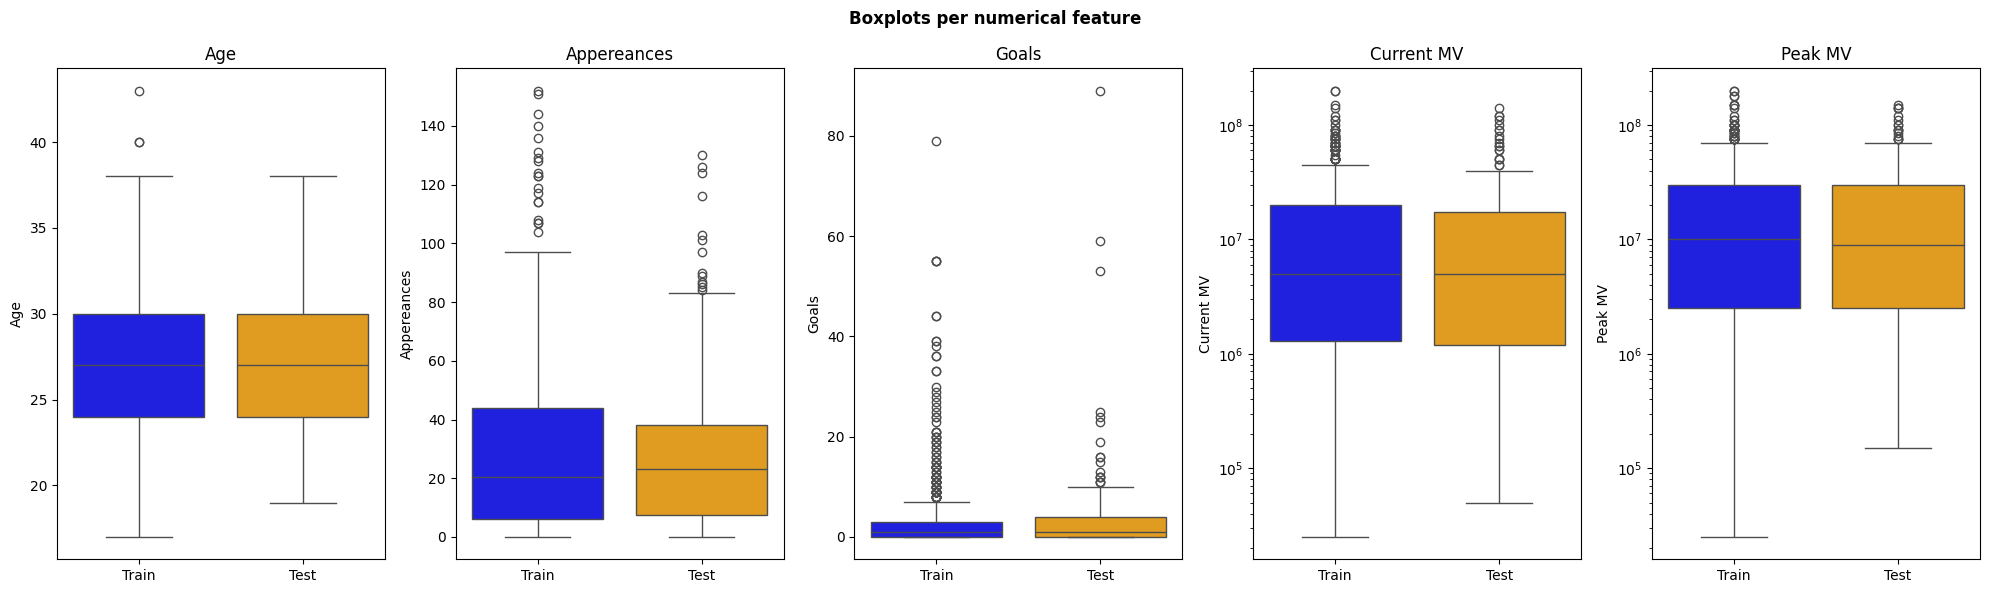

In [142]:
train_numeric = X_train.select_dtypes(include=[np.number]).copy()
train_numeric['Current MV'] = y_train
train_numeric['Set'] = 'Train'

test_numeric = X_test.select_dtypes(include=[np.number]).copy()
test_numeric['Current MV'] = y_test
test_numeric['Set'] = 'Test'

# get all numerical columns to evaluate
combined = pd.concat([train_numeric, test_numeric], ignore_index=True)

numeric_cols = ['Age', 'Appereances', 'Goals', 'Current MV', 'Peak MV']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data = combined, x = 'Set', y = col, ax = ax, palette = ['blue', 'orange'], hue = 'Set', legend = False)
    ax.set_title(col)
    ax.set_xlabel('')

    # had to add this because the market valuations were really flattened and hard to detect
    if col in ['Current MV', 'Peak MV']:
        ax.set_yscale('log')

plt.suptitle('Boxplots per numerical feature', fontweight = 'bold')
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
# it helps see the graphs side by side
plt.tight_layout()
plt.show()

To approach the visualisation and comparison of the market value price distributions i opted for a stacked bar chart because it helps us see how the whole dataset looks, while also we can compare visually the normal distribution of the color orange to be about 25% of the total height of the bar. This rule generally keeps up but fails in the extremes, as uneven distribution there is very common.

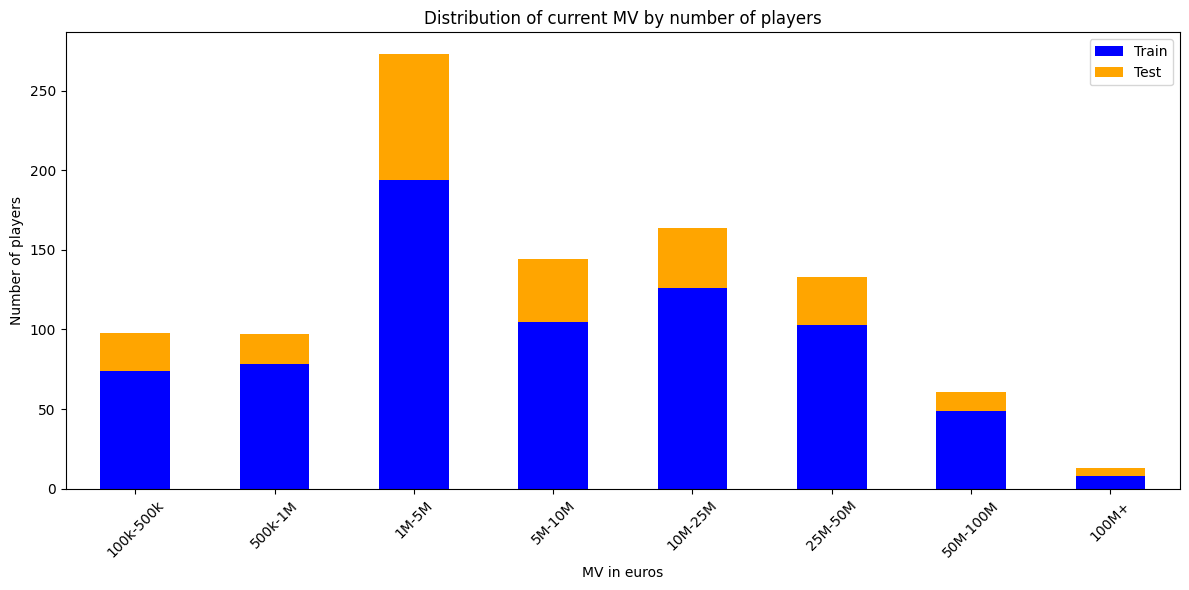

In [143]:
range_money = [100000, 500000, 1000000, 5000000, 10000000, 25000000, 50000000, 100000000, np.inf]
labels = ['100k-500k', '500k-1M', '1M-5M', '5M-10M', '10M-25M', '25M-50M', '50M-100M', '100M+']

train_bins = pd.cut(y_train, bins = range_money, labels=labels, right=False)
test_bins = pd.cut(y_test, bins = range_money, labels=labels, right=False)

train_counts = train_bins.value_counts()[labels]
test_counts = test_bins.value_counts()[labels]

combined_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts})

combined_df.plot(
    kind='bar', 
    stacked=True,
    figsize=(12, 6), 
    color=['blue', 'orange']
)

plt.title('Distribution of current MV by number of players')
plt.xlabel('MV in euros')
plt.ylabel('Number of players')
plt.xticks(rotation=45)
plt.legend() 
plt.savefig('mv_distribution.png', dpi=150, bbox_inches='tight')
plt.tight_layout() 
plt.show()

Check player role categroy distribution across the players. Values are as expected with goalkeepers being significantly less than other categories (usually 3 per team) and other categories pretty close but skewed towards defenders as most squads take 3-4 of them in the total 11. These facts stand for both test and train sets

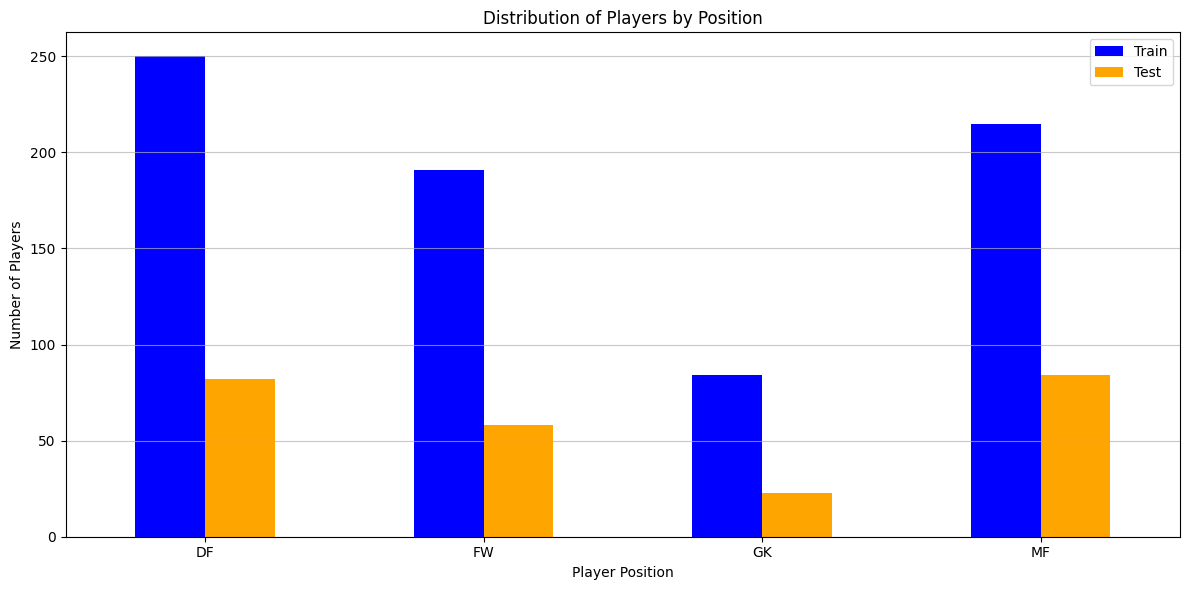

In [144]:
position_counts_train = X_train['Position'].value_counts()
position_counts_test = X_test['Position'].value_counts()

combined_df = pd.DataFrame({'Train': position_counts_train, 'Test': position_counts_test})

combined_df.plot(
    kind = 'bar', 
    stacked = False,
    figsize = (12, 6), 
    color = ['blue', 'orange']
)

plt.title('Distribution of Players by Position')
plt.xlabel('Player Position')
plt.ylabel('Number of Players')
plt.xticks(rotation = 0)
plt.grid(axis = 'y', alpha = 0.7)
plt.legend() 
plt.savefig('position.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

See normal distribution of how valuable some roles are compared to others. We observe crazy skews in all positions except GK where big outliers are higlighted. The symetry of the left and right handside of the graphs is very good and shows good data splitage. Forwards have the biggest difference in price (seen by how the graph is alungated and not mountaiish like the goalkeepers).

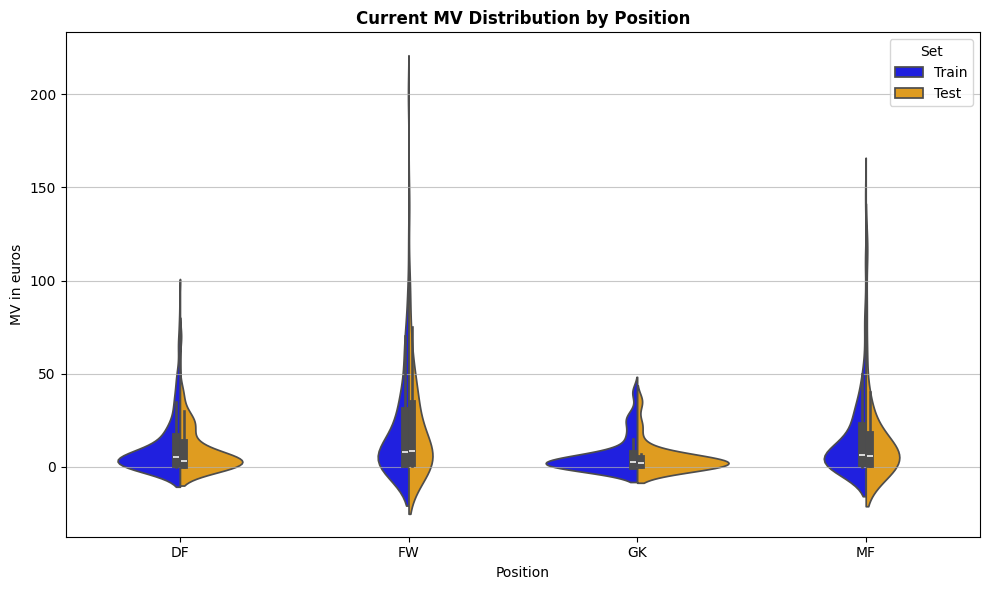

In [145]:
train_data_eda = X_train.copy()
train_data_eda['Current MV'] = y_train
train_data_eda['Set'] = 'Train'

test_data_eda = X_test.copy()
test_data_eda['Current MV'] = y_test
test_data_eda['Set'] = 'Test'

combined_eda = pd.concat([train_data_eda, test_data_eda], ignore_index=True)
combined_eda['Current MV'] = combined_eda['Current MV'] / 1000000

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=combined_eda, 
    x='Position', 
    y='Current MV', 
    hue='Set',
    split=True,
    palette=['blue', 'orange']
)

plt.title('Current MV Distribution by Position', fontweight='bold')
plt.xlabel('Position')
plt.ylabel('MV in euros')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.savefig('violin.png', dpi=150, bbox_inches='tight')
plt.show()

Use the bool Apex value to see what perecetage of players are donsideredd to be in their peak in their career. This would be more typical for younger players who are still projected to grow

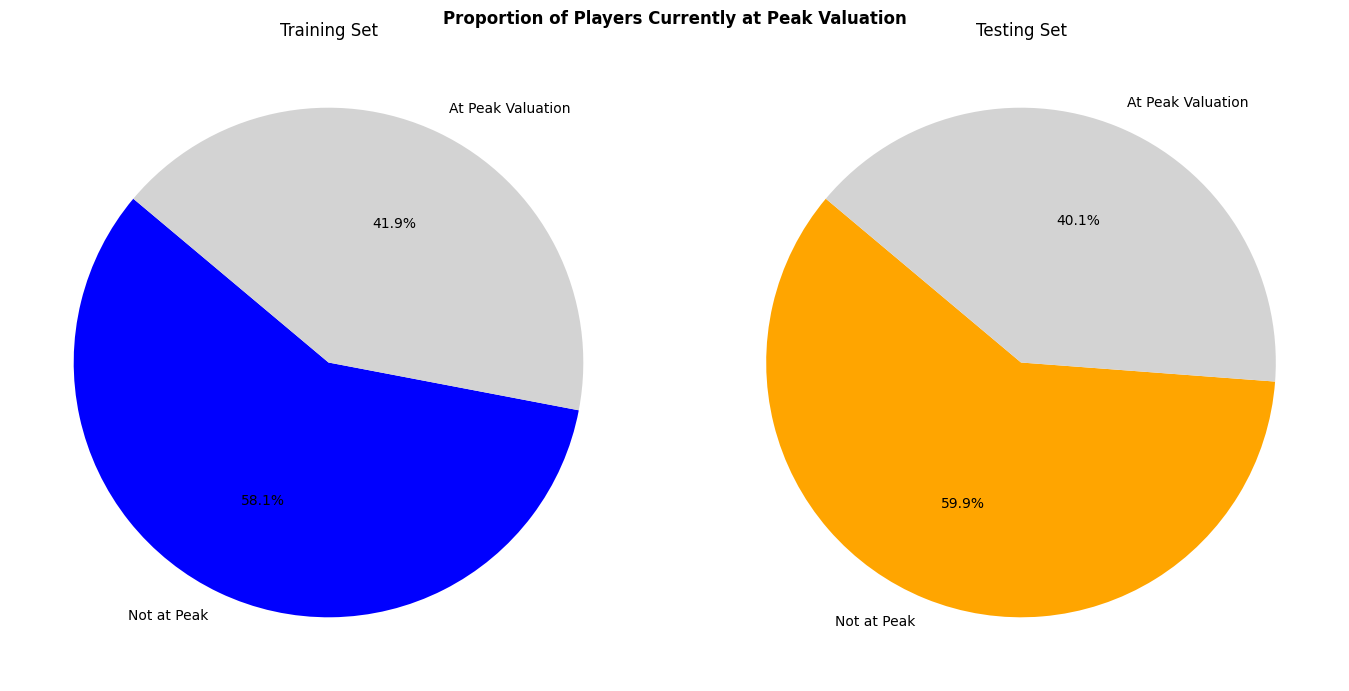

In [146]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 7))

train_counts = X_train['Apex MV'].value_counts()
test_counts = X_test['Apex MV'].value_counts()

labels = train_counts.index.map({False: 'Not at Peak', True: 'At Peak Valuation'})

ax1.pie(
    train_counts.values, 
    labels = labels, 
    autopct = '%1.1f%%', 
    startangle = 140, 
    colors = ['blue', 'lightgray']
)
ax1.set_title('Training Set')

ax2.pie(
    test_counts.values, 
    labels = labels, 
    autopct = '%1.1f%%', 
    startangle = 140, 
    colors = ['orange', 'lightgray']
)
ax2.set_title('Testing Set')

fig.suptitle('Proportion of Players Currently at Peak Valuation', fontweight = 'bold')

plt.tight_layout()
plt.savefig('apex_pie.png', dpi=150, bbox_inches='tight')
plt.show()

Used a cool imported library that helped the plot be more spaced out for the country names as they were overlapping really hard: [Adjusttext](https://adjusttext.readthedocs.io/en/latest/)

The inherent problem is that squads by regulation should be between 23 - 26 players. Fact is that at the current date some squads still have provisional squads that include between 35 - 55 players (ex: Argentina who is a big outlier here). This is a really important find and I decided to keep in this case total data (including both test and train data) in the same chart to see the number of player better. 

This is a great example of a inherent problem missed in the tabular display in the describe() method versus a graphical visualisation that makes outliers very visible.

For better visualisation I added a green bar arround 22.5 and 26.5 to see the teams that  have confirmed squads in the specified range. Also a red bar for the interval allowed for provisional squads. This doesnt affect our data calculation it would be a major data loss if such squads were eliminated.

Therefore the elimination of players inside the player_df earlier clearly eliminated some players for countries where they didnt have valutations (lots of countries behind the greenline).

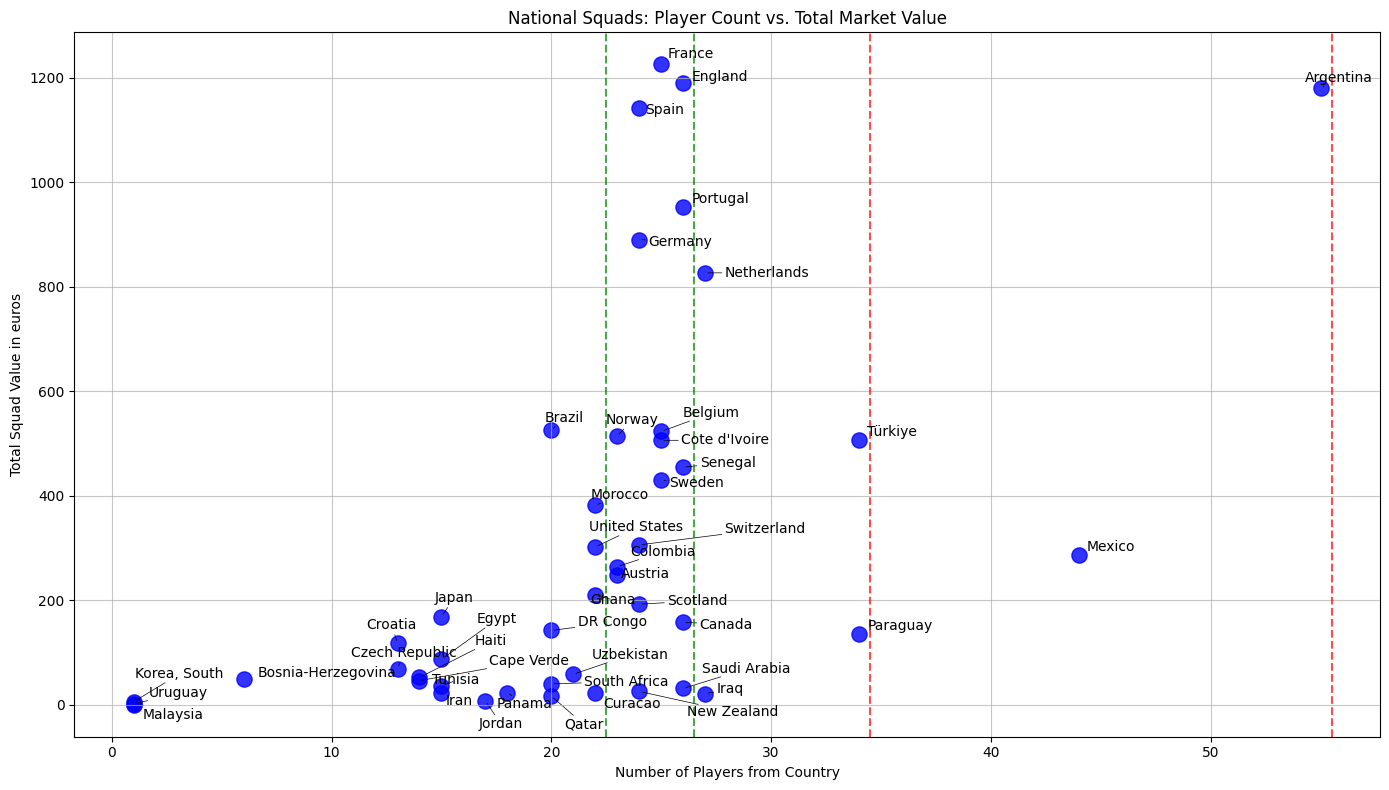

In [147]:

country_scatter = players_df.groupby('Country', observed=False).agg(
    player_count = ('Current MV', 'count'),
    total_value_m = ('Current MV', 'sum')
)

country_scatter['total_value_m'] = country_scatter['total_value_m'] / 1000000

plt.figure(figsize=(14, 8))

plt.scatter(
    country_scatter['player_count'], 
    country_scatter['total_value_m'], 
    color='blue',
    s = 120, 
    alpha = 0.8
)

texts = []
for country, row in country_scatter.iterrows():
    texts.append(plt.text(row['player_count'], row['total_value_m'], country))

# add separator lines to see which current squads respect the rules
plt.axvline(x=22.5, color='green', linestyle ='--', alpha=0.7)
plt.axvline(x=26.5, color='green', linestyle ='--', alpha=0.7)
plt.axvline(x=34.5, color='red', linestyle ='--', alpha=0.7)
plt.axvline(x=55.5, color='red', linestyle ='--', alpha=0.7)

# make country names more visible
adjust_text(texts, arrowprops=dict(arrowstyle = '-', lw = 0.5))

plt.title('National Squads: Player Count vs. Total Market Value')
plt.xlabel('Number of Players from Country')
plt.ylabel('Total Squad Value in euros')

plt.grid(True, alpha = 0.7)
plt.tight_layout()
plt.savefig('country_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation matrices for the training set and testing set. This is really important because it pretty much shows the weights of each column will have when we apply regression. Most importantly we have to look at the Current_MV column and how big the impact is by other values. What we observe:
* Peak MV has the biggest effect on Current MV on both sets, this is supported by the fact that above 40% of players are in their peak (peak valuation = current valuation)
* Goals are more important for the valuation of a player inside the training set compared to the test set

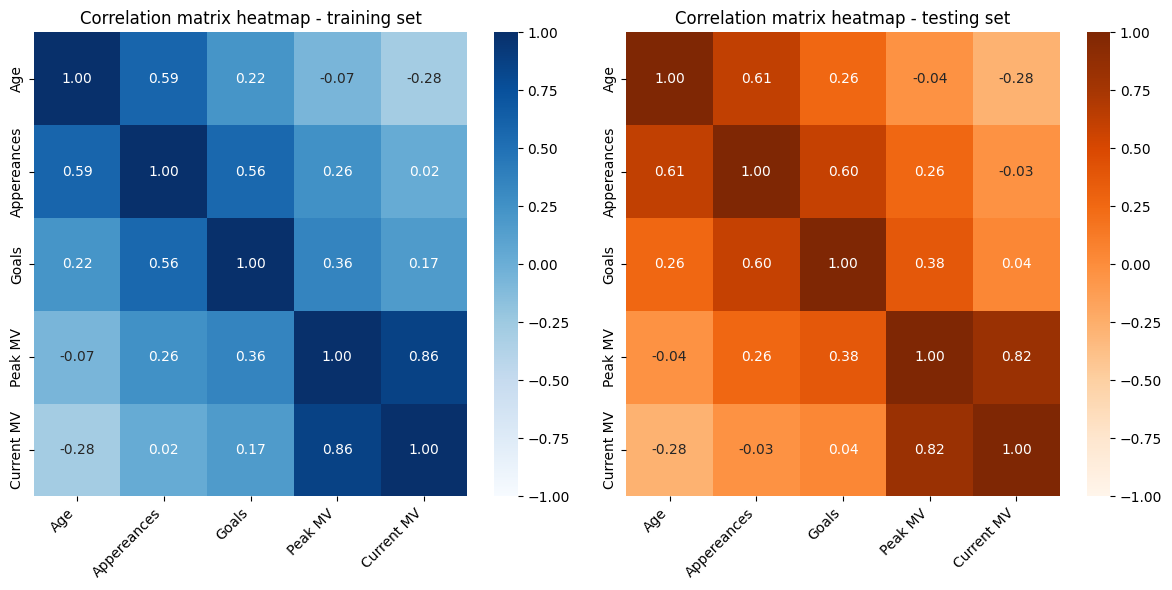

In [148]:
train_numeric = X_train.select_dtypes(include=[np.number]).copy()
train_numeric['Current MV'] = y_train 
matrix_train_numeric = train_numeric.corr()

test_numeric = X_test.select_dtypes(include=[np.number]).copy()
test_numeric['Current MV'] = y_test 
matrix_test_numeric = test_numeric.corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

i = 0
while i < 2:
    # instead of 2 code cells we just change wanted values and print the same type 
    if i == 0:
        matrix = matrix_train_numeric
        graph_title = 'Correlation matrix heatmap - training set'
        cmap_color = 'Blues'
    else:
        matrix = matrix_test_numeric
        graph_title = 'Correlation matrix heatmap - testing set'
        cmap_color = 'Oranges'

    sns.heatmap(matrix, annot=True, cmap = cmap_color, fmt=".2f", vmin=-1, vmax=1, ax=axes[i])
    axes[i].set_title(graph_title)
    plt.setp(axes[i].get_xticklabels(), rotation = 45, ha = 'right')

    i = i + 1

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Training and running the model needs data to be numbers so we first normalize objects to numbers and then because we have a regression problem (we want to evaluate a number), i chose to go with the RandomForestRegressor to make the best prediction. After predicting on the test set we give the model stats.

In [149]:
# our model cant work with strings so we transform objects into numbers for the encoder
X_train_encoded = pd.get_dummies(
    X_train, 
    columns=['Position', 'Club', 'Club League', 'Country']
)
X_test_encoded = pd.get_dummies(
    X_test, 
    columns=['Position', 'Club', 'Club League', 'Country']
)

# train the regression model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.0f} EUR")
print(f"MAE:  {mae:,.0f} EUR")
print(f"R²:   {r2:.4f}")

RMSE: 6,086,166 EUR
MAE:  2,503,894 EUR
R²:   0.9266


Plot the predicted values against test values and see how they stack up against the actual test values. We can observe more outliers for more expensive players for who we do not have a lot of data but overall prediction is working. The R^2 value being close to 1 with not a huge dataset is great.

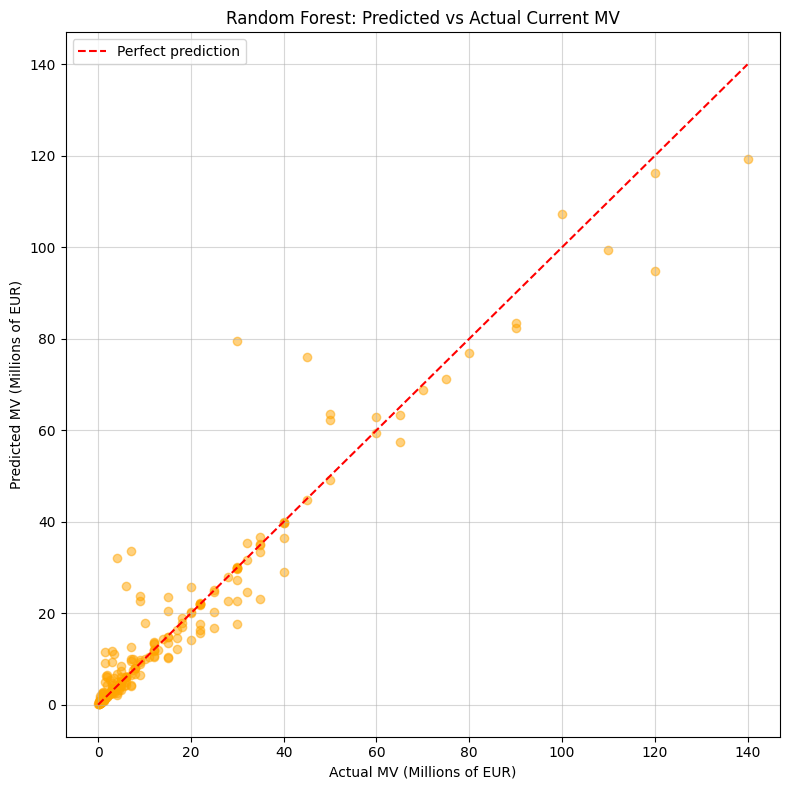

In [150]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test / 1000000, y_pred / 1000000, color='orange', alpha=0.5)

max_val = max(y_test.max(), y_pred.max()) / 1000000
plt.plot([0, max_val], [0, max_val], color = 'red', linestyle = '--', label='Perfect prediction')

plt.title('Random Forest: Predicted vs Actual Current MV')
plt.xlabel('Actual MV (Millions of EUR)')
plt.ylabel('Predicted MV (Millions of EUR)')
plt.legend()
plt.grid(alpha = 0.5)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()